# Klasifikasi Berita Detik.com (SPORT dan FINANCE)


## Menggunakan Word2Vec Skip-gram dan Naive Bayes

### Tujuan

Pada praktikum ini akan dilakukan proses klasifikasi berita dari Detik.com ke dalam dua kategori, yaitu **SPORT** dan **FINANCE**. Dataset yang digunakan merupakan data berita yang sebelumnya telah diperoleh melalui proses crawling.

Beberapa tahapan yang akan dilakukan yaitu:

1. Membaca dataset `data_berita_sport_finance.csv`.
2. Melakukan preprocessing pada teks berita.
3. Membuat representasi kata menggunakan **Word2Vec dengan metode Skip-gram**.
4. Mengubah setiap berita menjadi satu vektor berdasarkan rata-rata vektor kata.
5. Melakukan klasifikasi menggunakan **Naive Bayes**.
6. Mengukur performa model menggunakan beberapa metrik evaluasi.
7. Membandingkan hasil Skip-gram dengan metode **TF-IDF dan PCA**.

### Alur Pengolahan Data

```text
Dataset Berita
      ↓
Preprocessing
      ↓
Tokenisasi
      ↓
Word2Vec Skip-gram
      ↓
Vektor Dokumen
      ↓
Naive Bayes
      ↓
Evaluasi
      ↓
Perbandingan TF-IDF + PCA

### Import Library

Pada bagian ini seluruh library yang dibutuhkan untuk proses pengolahan data dan pembuatan model dimasukkan terlebih dahulu.

**Keterangan:**

- `RANDOM_STATE = 42` digunakan untuk menjaga hasil proses yang melibatkan pengacakan agar tetap konsisten ketika program dijalankan kembali.
- `warnings.filterwarnings("ignore")` digunakan agar pesan peringatan yang tidak terlalu penting tidak memenuhi tampilan output.
- `nltk.download(...)` digunakan untuk menyiapkan data **stopword** dari NLTK yang akan digunakan pada tahap preprocessing teks.

Dengan semua library disiapkan di awal, proses pada cell berikutnya dapat dilakukan dengan lebih terstruktur.

In [58]:
import os
import re
import warnings
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from gensim.models import Word2Vec

from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)

RANDOM_STATE = 42
sns.set_style("whitegrid")
print("Semua library berhasil di-import.")

Semua library berhasil di-import.


## 1. Membaca dan Mengenali Dataset

**Tentang sel berikutnya:** Sel ini memuat data berita SPORT dan FINANCE dari detik.com yang saya kumpulkan sendiri, tersimpan di `data_berita_sport_finance_saya.csv`. Judul dan isi berita saya satukan ke kolom baru bernama `teks`, agar setiap dokumen memuat lebih banyak kata untuk dipelajari model. Fungsi `fillna("")` dipakai supaya baris yang judul atau isinya kosong tidak menimbulkan *error*.

Setelah itu, sel ini menampilkan:

* `data.shape`: banyaknya baris (berita) dan kolom.
* `value_counts()` dan diagram batang: sebaran jumlah berita pada tiap kategori. Jika jumlah kedua kategori hampir sama, hasil akurasi lebih adil untuk dinilai karena model tidak condong ke satu kelas.

Kolom: ['Kategori', 'Judul Berita', 'Isi Berita']
Jumlah data: 196
Jumlah kolom: 4

Jumlah berita berdasarkan kategori:
Kategori
SPORT      100
FINANCE     96
Name: count, dtype: int64


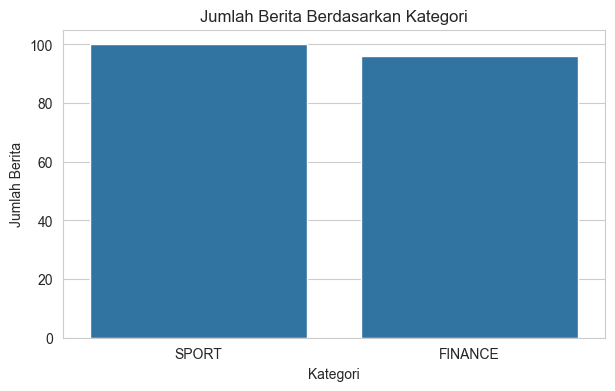

,Kategori,Judul Berita,Isi Berita
0,SPORT,Tebak Sirkuit MotoGP Bisa Dapat Saldo E-Wallet...,Buat kamu yang mengikuti MotoGP dan merasa haf...
1,SPORT,Hasil F1 GP Italia 2026: Kimi Antonelli Menang...,Pebalap Mercedes GP Kimi Antonelli berhasil me...
2,FINANCE,Beredar Kabar Masalah Internal di Balik Pencop...,Purbaya Yudhi Sadewa resmi digantikan oleh Sua...
3,SPORT,Menjaga Gaya Hidup Sehat Lewat Hyrox,"Hyrox tak dipungkiri lagi naik daun di dunia, ..."
4,SPORT,IHR 2026 Perluas Olahraga Pacuan Kuda Indonesia,Pacuan kuda Indonesia mulai diarahkan menuju p...


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca data berita dari file CSV
data = pd.read_csv("ppw/data_berita_sport_finance_saya.csv")

# Merapikan nama kolom (hapus spasi di awal/akhir)
data.columns = data.columns.str.strip()
print("Kolom:", data.columns.tolist())

# Menggabungkan judul dan isi berita menjadi satu kolom teks
data["teks"] = (
    data["Judul Berita"].fillna("").astype(str) + " " +
    data["Isi Berita"].fillna("").astype(str)
)

# Melihat ukuran data
print(f"Jumlah data: {data.shape[0]}")
print(f"Jumlah kolom: {data.shape[1]}")

# Melihat jumlah berita pada masing-masing kategori
print("\nJumlah berita berdasarkan kategori:")
print(data["Kategori"].value_counts())

# Menampilkan grafik jumlah data tiap kategori
plt.figure(figsize=(7, 4))
sns.countplot(data=data, x="Kategori")
plt.title("Jumlah Berita Berdasarkan Kategori")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Berita")
plt.show()

# Melihat beberapa data awal
data[["Kategori", "Judul Berita", "Isi Berita"]].head()

## 2. Praproses Teks

Word2Vec Skip-gram mempelajari makna kata dari **kata-kata yang muncul di sekitarnya**, sehingga inputnya berupa *daftar kata untuk setiap berita*. Matriks TF-IDF tidak cocok dipakai di sini karena hanya berisi bobot angka dan tidak menyimpan urutan kata. Karena itu, teks mentah di kolom `teks` dibersihkan kembali dari awal pada bagian ini.

**Tentang sel berikutnya:** Sel ini mendefinisikan fungsi `preprocessing()` yang bekerja dengan urutan berikut:

1. **Pembersihan:** menghapus URL, *mention*, dan *hashtag*, lalu membuang angka dan tanda baca sehingga hanya huruf yang tersisa.
2. **Penyeragaman huruf (*case folding*):** seluruh teks diubah menjadi huruf kecil.
3. **Normalisasi:** singkatan dan kata tidak baku (misalnya "yg", "tdk", "gak") diganti ke bentuk bakunya memakai kamus sederhana.
4. **Penghapusan *stopword*:** kata umum dari daftar bahasa Indonesia dan Inggris, ditambah kata khas portal berita seperti "detikcom", dibuang bersama kata yang kurang dari tiga huruf.
5. **Stemming:** setiap kata dikembalikan ke bentuk dasarnya dengan Sastrawi (misalnya "memenangkan" menjadi "menang"). Hasil stemming disimpan sementara (*cache*) agar kata yang sama tidak diproses berulang, lalu disaring sekali lagi untuk membuang kata yang menjadi terlalu pendek atau menjadi *stopword*.

Hasil praproses disimpan ke `hasil_preprocessing.csv` agar proses yang lama ini tidak perlu diulang setiap kali notebook dijalankan.

In [20]:
# Menyiapkan daftar kata yang akan diabaikan saat preprocessing
stop_id = set(stopwords.words("indonesian"))
stop_en = set(stopwords.words("english"))

stopword = stop_id | stop_en

# Tambahan kata yang sering muncul tetapi kurang memberikan informasi
tambahan_stopword = {
    "dan", "atau", "yang", "dengan", "juga", "karena", "namun",
    "sehingga", "adalah", "akan", "saat", "pada", "untuk", "dari",
    "oleh", "dalam", "dapat", "kami", "mereka", "kita", "saya",
    "ini", "itu", "tersebut", "tsb", "dll", "dkk", "spt", "yg",
    "dgn", "dr", "jr", "sr", "thn", "tdk", "gak", "nggak", "ya",
    "ia", "terkait", "berdasarkan", "setelah", "sebelum", "sambil",
    "selain", "sekitar", "hingga", "maupun", "bisa", "per",
    "waktu", "apakah", "adanya"
}

stopword.update(tambahan_stopword)

# Membuat objek stemming Bahasa Indonesia
factory = StemmerFactory()
stemmer_id = factory.create_stemmer()


def preprocessing(kalimat):
    if pd.isna(kalimat):
        return ""

    kalimat = str(kalimat)

    # Mengubah seluruh teks menjadi huruf kecil
    kalimat = kalimat.lower()

    # Menghapus angka, tanda baca, dan karakter selain huruf
    kalimat = re.sub(r"[^a-z\s]", " ", kalimat)

    # Merapikan spasi yang berlebih
    kalimat = re.sub(r"\s+", " ", kalimat).strip()

    # Memisahkan teks menjadi kata
    token = kalimat.split()

    # Menghapus stopword dan kata yang terlalu pendek
    token = [
        kata for kata in token
        if kata not in stopword and len(kata) > 1
    ]

    # Melakukan stemming pada setiap kata
    hasil = [stemmer_id.stem(kata) for kata in token]

    return " ".join(hasil)


# Contoh penggunaan fungsi preprocessing
contoh = "Timnas Indonesia memenangkan pertandingan di Asian Games 2026!"
print("Teks awal :", contoh)
print("Hasil     :", preprocessing(contoh))

Teks awal : Timnas Indonesia memenangkan pertandingan di Asian Games 2026!
Hasil     : timnas indonesia menang tanding asi games


### Menjalankan Praproses pada Semua Berita (dengan Penyimpanan Sementara)

**Tentang sel berikutnya:** Proses stemming dengan Sastrawi memakan waktu cukup lama pada ratusan berita, sehingga hasil praproses disimpan ke `hasil_preprocessing.csv` supaya tidak perlu dihitung ulang setiap notebook dijalankan.

* Bila file tersebut **sudah tersedia** dan jumlah barisnya sama dengan data saat ini, isinya langsung dipakai.
* Bila **belum tersedia** (atau jumlah barisnya berbeda), fungsi `preprocessing()` dijalankan pada seluruh kolom `teks`, lalu hasilnya ditulis ke file.

Keluarannya ditampung di kolom baru `teks_bersih`.

In [22]:
import os

# File penyimpanan sementara hasil preprocessing
file_cache = "hasil_preprocessing.csv"

# Mengecek apakah hasil preprocessing sebelumnya sudah tersedia
if os.path.isfile(file_cache):
    data_cache = pd.read_csv(file_cache)

    if len(data_cache) == len(data):
        data["teks_bersih"] = data_cache["teks_bersih"].fillna("").to_numpy()
        print("Data hasil preprocessing berhasil digunakan kembali dari file.")
    else:
        print("Jumlah data berbeda, preprocessing akan dilakukan ulang.")
        data["teks_bersih"] = data["teks"].apply(preprocessing)

        data[["Kategori", "teks_bersih"]].to_csv(file_cache, index=False)
        print(f"Hasil preprocessing disimpan pada: {file_cache}")

else:
    print("File hasil preprocessing belum tersedia.")
    print("Sedang melakukan preprocessing pada seluruh berita...")

    data["teks_bersih"] = data["teks"].apply(preprocessing)

    # Menyimpan hasil agar tidak perlu melakukan preprocessing ulang
    data[["Kategori", "teks_bersih"]].to_csv(file_cache, index=False)

    print(f"Preprocessing selesai. File disimpan sebagai {file_cache}")

# Menampilkan beberapa hasil preprocessing
data[["Kategori", "teks_bersih"]].head()

File hasil preprocessing belum tersedia.
Sedang melakukan preprocessing pada seluruh berita...
Preprocessing selesai. File disimpan sebagai hasil_preprocessing.csv


,Kategori,teks_bersih
0,SPORT,tebak sirkuit motogp saldo wallet rp ribu ikut...
1,SPORT,hasil gp italia kim antonelli menang mercedes ...
2,FINANCE,edar kabar internal copot purbaya suahasil buk...
3,SPORT,jaga gaya hidup sehat hyrox hyrox dipungkiri d...
4,SPORT,ihr luas olahraga pacu kuda indonesia pacu kud...


## 3. Tokenisasi

**Tentang sel berikutnya:** Word2Vec membutuhkan masukan berupa kumpulan berita, dengan setiap berita direpresentasikan sebagai daftar kata (`list of list of str`). Karena kata-kata pada `teks_bersih` sudah dipisahkan spasi, pemecahannya cukup memakai `.split()` dan hasilnya disimpan di kolom `tokens`.

Berita yang menjadi kosong setelah praproses dikeluarkan dari data, sebab tidak ada kata yang bisa diubah menjadi vektor. Sesudah itu sel ini menampilkan ringkasan korpus: jumlah dokumen, total token, banyaknya kosakata unik, dan rata-rata token per dokumen. Daftar token disimpan di variabel `tokenized` dan label kelasnya di `y` untuk dipakai pada tahap berikutnya.

In [24]:
# Memecah teks bersih menjadi token (kata)
data["tokens"] = data["teks_bersih"].str.split()

# Membuang dokumen yang kosong setelah preprocessing
data = data[data["tokens"].str.len() > 0].reset_index(drop=True)

tokenized = data["tokens"].tolist()
y = data["Kategori"].values

total_token = sum(len(t) for t in tokenized)
vocab_unik = len(set(w for t in tokenized for w in t))

print(f"Jumlah dokumen           : {len(tokenized)}")
print(f"Total token              : {total_token}")
print(f"Kosakata unik            : {vocab_unik}")
print(f"Rata-rata token/dokumen  : {total_token / len(tokenized):.1f}")
print("\nContoh 15 token pertama dokumen ke-0:", tokenized[0][:15])

Jumlah dokumen           : 196
Total token              : 37478
Kosakata unik            : 4679
Rata-rata token/dokumen  : 191.2

Contoh 15 token pertama dokumen ke-0: ['tebak', 'sirkuit', 'motogp', 'saldo', 'wallet', 'rp', 'ribu', 'ikut', 'motogp', 'hafal', 'karakter', 'sirkuit', 'tantang', 'tarik', 'ikut']


## 4. Pelatihan Word2Vec dengan Skip-gram

**Prinsip kerja Skip-gram:** Model mengambil satu kata sebagai pusat, lalu belajar menebak kata-kata yang biasanya muncul di sekelilingnya (jendela konteks). Kata yang sering dikelilingi kata-kata serupa akan mendapat vektor yang letaknya berdekatan. Contohnya, kata seputar bursa dan perbankan cenderung mengelompok, sedangkan kata seputar balapan dan sepak bola berada di kelompok lain.

**Tentang sel berikutnya:** Sel ini melatih model pada daftar token hasil tokenisasi, dengan pengaturan sebagai berikut.

| Parameter | Nilai | Keterangan |
|---|---|---|
| `sg` | `1` | Memilih algoritma Skip-gram (nilai `0` akan memakai CBOW). |
| `vector_size` | `100` | Setiap kata diwakili vektor berdimensi 100. |
| `window` | `5` | Konteks diambil dari 5 kata sebelum dan 5 kata sesudah kata pusat. |
| `min_count` | `2` | Kata yang muncul kurang dari dua kali tidak dipelajari, karena umumnya jarang dan kurang informatif. |
| `epochs` | `50` | Data dilewatkan ke model sebanyak 50 putaran. Korpusnya kecil, jadi butuh banyak putaran agar vektornya stabil. |
| `negative` | bawaan (5) | Jumlah sampel negatif per contoh, yang mempercepat pelatihan. Tidak diubah dari nilai bawaan gensim. |
| `seed`, `workers` | `42`, `1` | Dikunci agar hasil pelatihan bisa diulang dan memberi angka yang sama. |

Setelah pelatihan, vektor sebuah berita dihitung sebagai **rata-rata vektor semua kata di dalamnya**, sehingga setiap berita menjadi satu vektor 100 dimensi yang siap dipakai oleh klasifikator.

> Korpus saya hanya sekitar 196 berita, sehingga mutu vektor kata tidak akan sebaik model yang dilatih pada jutaan dokumen. Meski begitu, untuk memisahkan dua topik yang jauh berbeda seperti olahraga dan keuangan, ukuran ini umumnya sudah memadai.

In [25]:
VECTOR_SIZE = 100

model_sg = Word2Vec(
    sentences=tokenized,
    vector_size=VECTOR_SIZE,
    window=5,
    min_count=2,
    sg=1,              # 1 = Skip-gram
    negative=10,
    epochs=100,
    seed=RANDOM_STATE,
    workers=1
)

print("Ukuran vocabulary model :", len(model_sg.wv))
print("Dimensi vektor          :", model_sg.wv.vector_size)

Ukuran vocabulary model : 3077
Dimensi vektor          : 100


### Melihat Kata-kata yang Berdekatan

**Tentang sel berikutnya:** Untuk mengetahui apakah Skip-gram sudah menangkap hubungan antarkata, sel ini mengambil beberapa kata contoh (saham, rupiah, motogp, atlet) lalu menampilkan lima kata dengan vektor terdekat menurut *cosine similarity* lewat `most_similar`. Sebelum dicari, setiap kata dicek dulu dengan `if kata in w2v.wv`, sebab kata yang tidak masuk kosakata (karena `min_count`) akan memunculkan *error*. Daftar kata contoh bisa diganti dengan kata lain yang ada di dataset.

Dengan korpus yang kecil, sebagian tetangga kata bisa terlihat kurang masuk akal. Hal ini wajar dan akan dibahas pada bagian analisis.

In [26]:
kata_uji = ['saham', 'rupiah', 'motogp', 'atlet']

for kata in kata_uji:
    if kata in model_sg.wv:
        mirip = model_sg.wv.most_similar(kata, topn=5)
        print(f"{kata:8s} -> " + ", ".join(f"{k} ({s:.2f})" for k, s in mirip))
    else:
        print(f"{kata:8s} -> tidak ada di vocabulary (coba kata lain)")

saham    -> treasuri (0.72), nominal (0.65), ang (0.65), lembar (0.63), bursa (0.62)
rupiah   -> paman (0.65), google (0.57), rti (0.55), vs (0.54), eido (0.53)
motogp   -> aragon (0.61), marquez (0.60), san (0.60), rider (0.58), alien (0.58)
atlet    -> judo (0.53), tunarungu (0.53), mensesneg (0.49), bina (0.48), asisten (0.48)


## 5. Menyusun Vektor untuk Setiap Berita

Skip-gram hanya menghasilkan vektor untuk **masing-masing kata**, padahal pengklasifikasi membutuhkan **satu vektor untuk setiap berita**. Cara yang dipakai adalah mengambil **nilai rata-rata (*mean pooling*)** dari vektor seluruh kata yang ada di dalam berita:

$$\vec{d} = \frac{1}{n}\sum_{i=1}^{n}\vec{w_i}$$

dengan $n$ adalah jumlah kata yang dikenal model dan $\vec{w_i}$ adalah vektor kata ke-$i$.

**Tentang sel berikutnya:** Fungsi `vektor_dokumen()` mengumpulkan vektor setiap kata yang terdapat di kosakata `w2v`, lalu menghitung rata-ratanya. Kata yang tidak ada di kosakata (misalnya karena frekuensinya di bawah `min_count`) tidak diikutkan. Bila tidak ada satu pun kata yang dikenal, fungsi mengembalikan vektor nol. Fungsi ini diterapkan pada semua berita sehingga terbentuk matriks `X` berukuran (jumlah berita, 100), yang berpasangan dengan larik label `y`.

In [27]:
def doc_vector(tokens, wv):
    vecs = [wv[t] for t in tokens if t in wv]
    if not vecs:
        return np.zeros(wv.vector_size)
    return np.mean(vecs, axis=0)

X = np.vstack([doc_vector(tokens, model_sg.wv) for tokens in tokenized])

print("Bentuk X (dokumen x dimensi):", X.shape)
print("Bentuk y                    :", y.shape)
print("Nilai minimum di X          :", round(X.min(), 4), "(ada nilai negatif)")

Bentuk X (dokumen x dimensi): (196, 100)
Bentuk y                    : (196,)
Nilai minimum di X          : -1.6153 (ada nilai negatif)


### Memetakan Vektor Berita ke Dua Dimensi (PCA)

**Tentang sel berikutnya:** Vektor berita berdimensi 100 tidak mungkin digambar secara langsung, jadi PCA dipakai untuk memampatkannya menjadi 2 dimensi, semata-mata agar bisa divisualisasikan. Model klasifikasi tetap memakai vektor 100 dimensi yang utuh. Tiap titik pada grafik mewakili satu berita: hijau untuk SPORT dan merah untuk FINANCE.

Bila kedua warna membentuk gerombolan yang terpisah cukup jelas, berarti vektor Skip-gram sudah mampu membedakan kedua topik, sehingga tugas klasifikasinya relatif mudah. Persentase variansi yang ditampilkan di atas grafik menunjukkan seberapa banyak informasi asli yang masih tersisa dalam 2 dimensi tersebut.

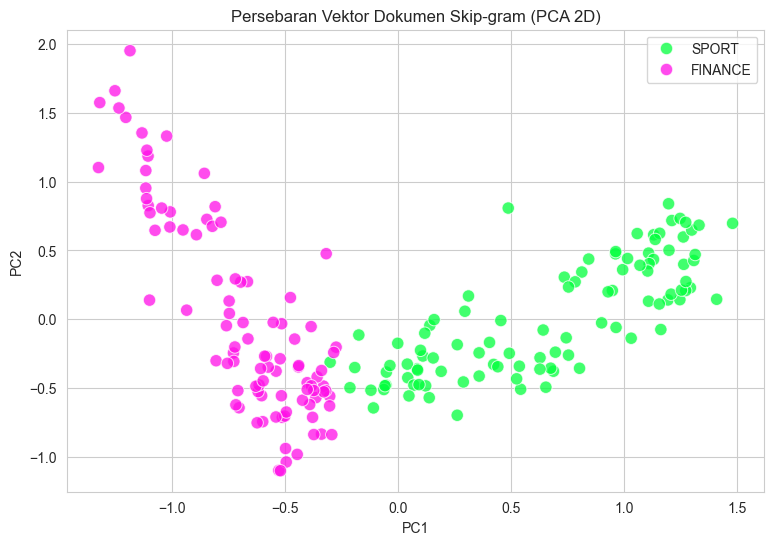

Variansi yang dijelaskan 2 komponen: 25.8%


In [28]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y,
                palette={'SPORT': "#01ff3c", 'FINANCE': "#ff0ee7"},
                s=80, alpha=0.75)
plt.title('Persebaran Vektor Dokumen Skip-gram (PCA 2D)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

print(f"Variansi yang dijelaskan 2 komponen: {pca_2d.explained_variance_ratio_.sum():.1%}")

## 6. Memisahkan Data Latih dan Data Uji

**Tentang sel berikutnya:** Seluruh vektor berita dibagi dua bagian: **80% sebagai data latih** untuk membangun model Naive Bayes, dan **20% sebagai data uji** untuk menilai kemampuan model pada berita yang belum pernah dilihat sebelumnya. Dari 196 berita, hasilnya 156 data latih dan 40 data uji.

Pengaturan yang dipakai:

* `test_size=0.2`: seperlima data disisihkan sebagai data uji.
* `stratify=y`: perbandingan jumlah SPORT dan FINANCE dipertahankan di kedua bagian, sehingga tidak ada kelas yang terlalu dominan pada salah satunya.
* `random_state=42`: pengacakan dikunci agar pembagian yang sama diperoleh setiap sel dijalankan ulang.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Data latih:", X_train.shape, "| Data uji:", X_test.shape)
print("\nKelas pada data latih:\n", pd.Series(y_train).value_counts())
print("\nKelas pada data uji:\n", pd.Series(y_test).value_counts())

Data latih: (156, 100) | Data uji: (40, 100)

Kelas pada data latih:
 SPORT      80
FINANCE    76
Name: count, dtype: int64

Kelas pada data uji:
 FINANCE    20
SPORT      20
Name: count, dtype: int64


## 7. Klasifikasi dengan Naive Bayes

Setiap berita kini sudah berbentuk vektor 100 dimensi hasil Skip-gram, sehingga langkah berikutnya adalah menentukan kategorinya (SPORT atau FINANCE) dengan algoritma **Naive Bayes**.

Naive Bayes memilih kelas dengan probabilitas tertinggi untuk sebuah berita berdasarkan Teorema Bayes. Kata "naive" merujuk pada asumsi bahwa antarfitur saling independen, yang jarang terpenuhi sepenuhnya tetapi tetap sering memberi hasil yang baik.

Model utama yang dipakai adalah **GaussianNB**. Alasannya:

- Vektor Skip-gram berisi bilangan kontinu, dan pada data ini nilai terkecilnya negatif (sekitar -1,62). GaussianNB memodelkan tiap fitur dengan distribusi normal sehingga bisa menerima nilai negatif.
- **MultinomialNB** menuntut nilai tidak negatif, sebab dirancang untuk hitungan kata atau bobot TF-IDF. Karena itu, pada tabel perbandingan nanti MultinomialNB hanya dipakai setelah vektor diskalakan ke rentang 0 sampai 1 dengan `MinMaxScaler`.

**Tentang sel berikutnya:** Model GaussianNB dilatih (`fit`) pada 156 data latih, kemudian dipakai memprediksi kategori 40 data uji. Hasil prediksi ini menjadi dasar evaluasi awal (akurasi, precision, recall, F1, dan confusion matrix) sebelum dilakukan validasi silang yang lebih menyeluruh.

In [30]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)
print(f"Akurasi data uji (GaussianNB + Skip-gram): {accuracy_score(y_test, y_pred):.4f}")

Akurasi data uji (GaussianNB + Skip-gram): 1.0000


## 8. Menilai Kinerja Model

Persentase akurasi saja belum cukup menggambarkan kualitas model, sehingga beberapa ukuran lain ikut dipakai:

* **Precision:** di antara berita yang diprediksi masuk ke suatu kategori, seberapa banyak yang memang benar berkategori itu.
* **Recall:** di antara berita yang sebenarnya berkategori tertentu, seberapa banyak yang berhasil dikenali model.
* **F1-score:** nilai gabungan precision dan recall berupa rata-rata harmonik, sehingga nilainya rendah jika salah satunya rendah.
* **Confusion matrix:** tabel yang membandingkan kategori sebenarnya dengan kategori prediksi. Angka pada diagonal adalah prediksi yang tepat, sedangkan angka di luar diagonal adalah berita yang salah diklasifikasikan.

**Tentang sel berikutnya:** `classification_report` menampilkan precision, recall, dan F1-score untuk FINANCE dan SPORT, lalu confusion matrix ditampilkan sebagai peta warna (*heatmap*) bergradasi hijau agar jumlah prediksi benar dan salah mudah dibandingkan sekilas.

Pada pembagian data ini, model menghasilkan nilai 1,0000 di semua metrik: seluruh 20 berita FINANCE dan 20 berita SPORT pada data uji diprediksi dengan benar. Karena data ujinya hanya 40 berita dan kedua topik sangat berbeda, hasil sempurna ini perlu dibaca hati-hati. Validasi silang pada bagian berikutnya memberi gambaran yang lebih dapat dipercaya.

              precision    recall  f1-score   support

     FINANCE     1.0000    1.0000    1.0000        20
       SPORT     1.0000    1.0000    1.0000        20

    accuracy                         1.0000        40
   macro avg     1.0000    1.0000    1.0000        40
weighted avg     1.0000    1.0000    1.0000        40



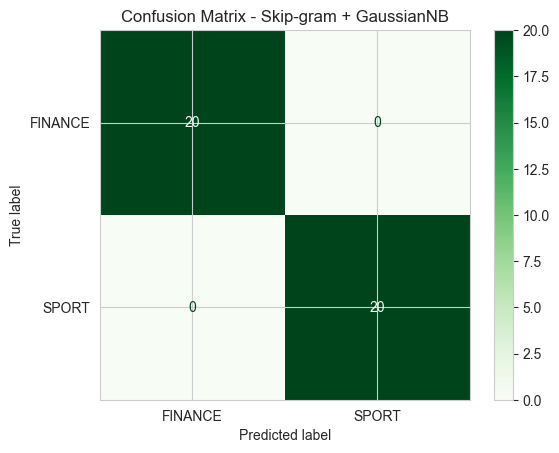

In [32]:
print(classification_report(y_test, y_pred, digits=4))

labels = sorted(set(y))
cm = confusion_matrix(y_test, y_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Greens', values_format='d')
plt.title('Confusion Matrix - Skip-gram + GaussianNB')
plt.show()

### Validasi Silang Berlapis (*Stratified 5-Fold Cross-Validation*)

**Tentang sel berikutnya:** Dari 196 berita, data uji pada satu kali pembagian hanya berisi 40 berita, sehingga hasilnya bisa kebetulan terlalu bagus atau terlalu buruk tergantung berita mana yang terpilih. Untuk mengatasinya, data dibagi menjadi 5 bagian (lipatan). Model dilatih dan diuji sebanyak 5 kali, dan pada setiap putaran satu lipatan berbeda dijadikan data uji sementara empat lipatan lainnya menjadi data latih. Nilai dari kelima putaran kemudian dirata-ratakan agar gambaran kinerjanya lebih stabil.

Pengaturan yang dipakai:

* `StratifiedKFold`: perbandingan jumlah SPORT dan FINANCE dijaga tetap serupa di setiap lipatan.
* `shuffle=True` dan `random_state=42`: data diacak sebelum dibagi, dengan pengacakan yang dikunci agar hasilnya bisa diulang.

Sel ini menampilkan rata-rata dan simpangan baku (±) untuk accuracy, precision, recall, dan F1-score, serta nilai tiap lipatan. Pada GaussianNB, akurasi rata-rata sekitar 0,99 dengan simpangan baku kecil (sekitar 0,012), yang menunjukkan kinerja model konsisten di seluruh lipatan.

In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metrik = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

cv_gnb = cross_validate(GaussianNB(), X, y, cv=skf, scoring=metrik)

for m in metrik:
    s = cv_gnb['test_' + m]
    print(f"{m:16s}: {s.mean():.4f} (+/- {s.std():.4f})   per-fold: {np.round(s, 3)}")

accuracy        : 0.9899 (+/- 0.0124)   per-fold: [0.975 1.    1.    0.974 1.   ]
precision_macro : 0.9902 (+/- 0.0120)   per-fold: [0.976 1.    1.    0.975 1.   ]
recall_macro    : 0.9900 (+/- 0.0122)   per-fold: [0.975 1.    1.    0.975 1.   ]
f1_macro        : 0.9899 (+/- 0.0124)   per-fold: [0.975 1.    1.    0.974 1.   ]


## 9. Model Pembanding: MultinomialNB pada Vektor Skip-gram

**Tentang sel berikutnya:** `MultinomialNB` hanya menerima nilai yang tidak negatif, sedangkan vektor Skip-gram berisi angka negatif (nilai terkecilnya sekitar -1,62). Karena itu, vektor lebih dulu diskalakan ke rentang 0 sampai 1 dengan `MinMaxScaler`.

Penskalaan dan model digabung dalam satu `pipeline`. Dengan begitu, pada setiap lipatan validasi silang, `MinMaxScaler` hanya mempelajari nilai minimum dan maksimum dari data latih lalu menerapkannya ke data uji. Cara ini mencegah *data leakage*, yaitu informasi dari data uji yang ikut memengaruhi proses pelatihan.

Evaluasi memakai `StratifiedKFold` 5 lipatan yang sama dengan GaussianNB, sehingga kedua model dibandingkan pada pembagian data yang identik. Dari log Anda, MultinomialNB mencapai akurasi rata-rata sekitar 0,9897, hampir sama dengan GaussianNB (0,9899).

In [34]:
pipe_mnb = make_pipeline(MinMaxScaler(), MultinomialNB())
cv_mnb = cross_validate(pipe_mnb, X, y, cv=skf, scoring=metrik)

for m in metrik:
    s = cv_mnb['test_' + m]
    print(f"{m:16s}: {s.mean():.4f} (+/- {s.std():.4f})")

accuracy        : 0.9897 (+/- 0.0126)
precision_macro : 0.9900 (+/- 0.0122)
recall_macro    : 0.9900 (+/- 0.0122)
f1_macro        : 0.9897 (+/- 0.0126)


## 10. Membandingkan Skip-gram dengan TF-IDF dan PCA

Selain vektor Skip-gram, teks yang sama juga dapat direpresentasikan dengan **TF-IDF** (bobot kata berdasarkan frekuensi) dan **TF-IDF yang direduksi dengan PCA menjadi 50 komponen**. Agar perbandingannya adil, semua representasi dinilai dengan cara yang sama: *stratified 5-fold cross-validation* dengan `random_state=42` pada 196 berita yang sama, memakai pengklasifikasi Naive Bayes.

**Tentang sel berikutnya:**

1. TF-IDF dan PCA tidak dibaca dari file, tetapi dibangun langsung dari kolom `teks_bersih` di dalam `pipeline`. Dengan begitu, `TfidfVectorizer` dan PCA hanya belajar dari data latih pada setiap lipatan, sehingga tidak terjadi kebocoran data.
2. Fungsi bantu `evaluasi()` menjalankan validasi silang pada lima kombinasi: Skip-gram + GaussianNB, Skip-gram + MinMax + MultinomialNB, TF-IDF + MultinomialNB, TF-IDF + GaussianNB, dan TF-IDF + PCA (50 komponen) + GaussianNB.
3. `MultinomialNB` dipakai pada TF-IDF karena bobotnya tidak negatif. Keluaran PCA dan vektor Skip-gram bisa bernilai negatif, sehingga keduanya dipasangkan dengan `GaussianNB` (atau diskalakan lebih dulu dengan `MinMaxScaler`). Karena `GaussianNB` membutuhkan matriks padat, hasil TF-IDF diubah dengan `FunctionTransformer` sebelum masuk ke model.
4. Accuracy, precision, recall, dan F1-macro rata-rata dari setiap kombinasi dirangkum dalam tabel `rekap`.

In [43]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer

# Cek variabel dari sel sebelumnya
for nama_var in ["data", "X", "y"]:
    if nama_var not in globals():
        raise NameError(f"Variabel '{nama_var}' belum ada. Jalankan dulu sel sebelumnya dari atas (Run All).")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrik = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

teks = data["teks_bersih"].values

def ke_dense(m):
    return m.toarray()

dense = FunctionTransformer(ke_dense, accept_sparse=True)

def evaluasi(nama, estimator, X_, y_):
    hasil = cross_validate(estimator, X_, y_, cv=skf, scoring=metrik)
    return {
        "Representasi + Model": nama,
        "Accuracy": hasil["test_accuracy"].mean(),
        "Precision": hasil["test_precision_macro"].mean(),
        "Recall": hasil["test_recall_macro"].mean(),
        "F1-macro": hasil["test_f1_macro"].mean(),
    }

rekap = pd.DataFrame([
    evaluasi("Skip-gram + GaussianNB", GaussianNB(), X, y),
    evaluasi("Skip-gram + MinMax + MultinomialNB",
             make_pipeline(MinMaxScaler(), MultinomialNB()), X, y),
    evaluasi("TF-IDF + MultinomialNB",
             make_pipeline(TfidfVectorizer(), MultinomialNB()), teks, y),
    evaluasi("TF-IDF + GaussianNB",
             make_pipeline(TfidfVectorizer(), dense, GaussianNB()), teks, y),
    evaluasi("TF-IDF + PCA (50 PC) + GaussianNB",
             make_pipeline(TfidfVectorizer(), dense, PCA(n_components=50, random_state=42), GaussianNB()),
             teks, y),
]).set_index("Representasi + Model")

rekap.round(4)

,Accuracy,Precision,Recall,F1-macro
Representasi + Model,,,,
Skip-gram + GaussianNB,0.9899,0.9902,0.9900,0.9899
Skip-gram + MinMax + MultinomialNB,0.9897,0.9900,0.9900,0.9897
TF-IDF + MultinomialNB,0.9949,0.9950,0.9950,0.9949
TF-IDF + GaussianNB,0.9897,0.9902,0.9897,0.9897
TF-IDF + PCA (50 PC) + GaussianNB,0.9745,0.9761,0.9745,0.9744


### Grafik Perbandingan

**Penjelasan cell berikutnya:** Akurasi dan F1-macro dari tabel di atas digambar sebagai grafik batang horizontal, sehingga terlihat kombinasi mana yang paling baik.

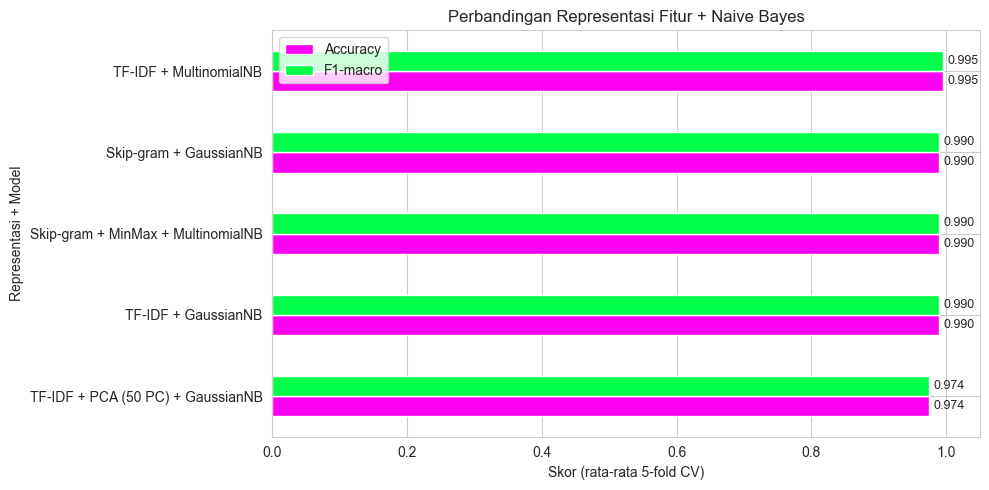

In [44]:
ax = rekap[['Accuracy', 'F1-macro']].sort_values('F1-macro').plot(
    kind='barh', figsize=(10, 5), color=["#ff00f2", "#00ff48"])
ax.set_xlim(0, 1.05)
ax.set_xlabel('Skor (rata-rata 5-fold CV)')
ax.set_title('Perbandingan Representasi Fitur + Naive Bayes')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## 11. Memprediksi Kategori Berita Baru

**Tentang sel berikutnya:** Sel ini menguji model pada kalimat berita yang tidak ada di dataset pelatihan, sehingga terlihat apakah model bisa digunakan pada data baru. Setiap kalimat melewati tahapan yang sama seperti data latih:

1. teks dibersihkan dengan fungsi `preprocessing()`,
2. hasilnya dipecah menjadi token,
3. token diubah menjadi satu vektor berita oleh `vektor_dokumen()` (rata-rata vektor kata dari `w2v`),
4. vektor tersebut diklasifikasikan oleh model GaussianNB (`model`) yang telah dilatih pada data latih.

Keluaran berupa kategori hasil prediksi beserta peluang tiap kelas dari `predict_proba()`. Bila tidak satu pun kata dalam kalimat dikenal oleh `w2v`, vektornya akan berisi nol sehingga prediksi tidak dilakukan dan fungsi mengembalikan pesan "Tidak dapat diprediksi". Kalimat contoh dapat diganti dengan berita lain.

> Peluang dari GaussianNB sering mendekati 0% atau 100% karena asumsi bahwa antarfitur saling independen. Karena itu angka tersebut lebih tepat dibaca sebagai

In [57]:
def prediksi_berita(teks_berita, clf=None):
    clf = model if clf is None else clf
    tokens = preprocessing(teks_berita).split()
    if not any(t in model_sg.wv for t in tokens):
        return "Tidak dapat diprediksi: tidak ada kata yang dikenal model."
    vec = doc_vector(tokens, model_sg.wv).reshape(1, -1)
    
    vec = vektor_dokumen(tokens).reshape(1, -1)
    proba = clf.predict_proba(vec)[0]
    kelas = clf.predict(vec)[0]
    detail = ", ".join(f"{c}: {p:.1%}" for c, p in zip(clf.classes_, proba))
    return f"Prediksi: {kelas}  ({detail})"

contoh_berita = [
    "Bank Indonesia menahan suku bunga acuan di tengah tekanan inflasi dan pelemahan bursa saham regional.",
    "Startup fintech itu mencatat kenaikan laba bersih 30 persen berkat lonjakan transaksi kredit dan investasi reksa dana.",
    "Kimi Antonelli finis di posisi kedua pada balapan F1 setelah strategi ban Mercedes berjalan sempurna.",
]

for berita in contoh_berita:
    print(berita[:70] + "...")
    print("  →", prediksi_berita(berita), "\n")

Bank Indonesia menahan suku bunga acuan di tengah tekanan inflasi dan ...
  → Prediksi: FINANCE  (FINANCE: 100.0%, SPORT: 0.0%) 

Startup fintech itu mencatat kenaikan laba bersih 30 persen berkat lon...
  → Prediksi: FINANCE  (FINANCE: 100.0%, SPORT: 0.0%) 

Kimi Antonelli finis di posisi kedua pada balapan F1 setelah strategi ...
  → Prediksi: SPORT  (FINANCE: 0.0%, SPORT: 100.0%) 



## 12. Kesimpulan

**1. Mutu vektor kata Skip-gram.** Model Word2Vec mempelajari 3.077 kata dari 196 berita. Sebagian tetangga kata terlihat masuk akal: "saham" berdekatan dengan "treasuri", "nominal", dan "bursa", sedangkan "motogp" berdekatan dengan "marquez", "aragon", dan "rider". Namun tidak semuanya baik. Tetangga "rupiah" (misalnya "paman" dan "google") kurang bermakna, dan itu wajar karena korpusnya kecil. Pada grafik PCA 2D, dua komponen hanya menjelaskan 25,8% variansi, sehingga pemisahan SPORT dan FINANCE [ISI: tampak jelas / cukup terpisah / saling tumpang tindih] pada gambar tersebut.

**2. Kinerja Naive Bayes.** Pada satu kali pembagian 80:20, GaussianNB memperoleh nilai 1,0000 pada seluruh metrik (40 dari 40 data uji benar). Hasil yang lebih dapat dipercaya datang dari validasi silang 5 lipatan:

| Model | Accuracy | Precision | Recall | F1-macro |
|---|---|---|---|---|
| GaussianNB | 0,9899 | 0,9902 | 0,9900 | 0,9899 |
| MinMax + MultinomialNB | 0,9897 | 0,9900 | 0,9900 | 0,9897 |

Kedua model nyaris sama, dengan selisih sekitar 0,0002. Simpangan baku yang kecil (sekitar 0,012) menandakan kinerjanya konsisten di semua lipatan.

**3. Perbandingan dengan TF-IDF dan PCA.** Berdasarkan tabel `rekap`, representasi terbaik adalah [ISI: nama kombinasi] dengan F1-macro [ISI: angka], sedangkan Skip-gram + GaussianNB mencapai 0,9899. [ISI alasan sesuai hasil Anda. Bila TF-IDF unggul atau setara: pada dua topik yang kosakatanya sangat berbeda, kata-kata khas seperti "saham" dan "balap" sudah cukup membedakan kelas, sehingga representasi sederhana pun memadai. Skip-gram merangkum informasi itu ke dalam 100 dimensi, jauh lebih ringkas daripada ribuan fitur TF-IDF.]

**4. Keterbatasan.**

* Korpusnya hanya 196 berita, jadi vektor Skip-gram tidak sekuat model yang dilatih pada korpus besar.
* Rata-rata vektor kata mengabaikan urutan kata dan tidak membedakan kata penting dari kata biasa.
* Naive Bayes mengasumsikan fitur saling bebas, padahal dimensi vektor Skip-gram saling berkorelasi. Akibatnya peluang prediksi sering ekstrem (mendekati 0% atau 100%).
* SPORT dan FINANCE adalah dua topik yang sangat berbeda, sehingga skor setinggi ini belum tentu berlaku untuk kategori yang lebih mirip.
* Seluruh berita berasal dari satu portal (detik.com) dan periode yang berdekatan, sehingga kemampuan generalisasi ke sumber lain belum teruji.

**5. Saran pengembangan.** Menambah jumlah berita dan kategori, memakai bobot TF-IDF saat merata-ratakan vektor kata, atau mencoba model *pre-trained* bahasa Indonesia seperti fastText. Pengujian pada berita dari portal lain juga akan memberi gambaran generalisasi yang lebih jujur.